# Research Notebook
This notebook is an exact cell‑structured version of the provided Python research script.
No computational logic has been changed. Cells are only separated for clarity and execution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
from scipy.optimize import brentq
from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter


In [2]:
# ============================================================
# Global plotting style

In [3]:
# ============================================================
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "axes.linewidth": 1.0,
    "lines.linewidth": 1.8,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
})

COL = {
    "base": "#1f77b4",
    "tr":   "#d62728",
    "aux":  "#2ca02c",
    "res":  "#9467bd",
    "shade":"#f2c14e",
    "dark": "#222222",
}

def beautify_linear_ax(ax):
    ax.grid(True, alpha=0.22, lw=0.7)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which="both", top=True, right=True)

def beautify_log_ax(ax):
    ax.grid(True, which="major", alpha=0.22, lw=0.7)
    ax.grid(True, which="minor", alpha=0.10, lw=0.4)
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(which="both", top=True, right=True)


In [4]:
# ============================================================
# Constants

In [5]:
# ============================================================
G = 6.67430e-11
c = 299792458.0
MSUN = 1.98847e30
PC = 3.085677581491367e16
GPC = 1e9 * PC
YEAR = 31557600.0

# surrogate LISA arm transfer scale
L_LISA = 2.5e9
f_star = c / (2.0 * np.pi * L_LISA)


In [6]:
# ============================================================
# Parameters

In [7]:
# ============================================================
pars = {
    # source
    "M_BH_Msun": 2.0e5,
    "mu_NS_Msun": 1.4,
    "ahat": 0.90,
    "distance_Gpc": 1.0,
    "iota": 0.50,
    "lambda_ecl": 1.10,
    "beta_ecl": 0.35,
    "psi_pol": 0.60,

    # observation
    "Tobs_yr": 0.35,
    "dt": 10.0,

    # transition model
    "transition_model": "mixed",   # "step" or "mixed"
    "Lambda_H": 450.0,
    "Lambda_Q": 120.0,
    "vc": 0.24,
    "vh": 0.34,
    "vq": 0.40,

    # tidal-response sector
    "kappa0": 0.03,
    "h2": 0.10,
    "h3s": 0.02,
    "h4": 0.00,

    # numerical grid
    "Nv": 70000,
    "v_floor": 0.03,
    "v_end_factor": 0.985,

    # flux-root safety
    "flux_root_safety": 0.98,
    "flux_scan_points": 4000,

    # effective multimode surrogate
    "modes": [(2, 1.0), (3, 0.40), (4, 0.20), (5, 0.10), (6, 0.05)],

    # stability floor for denominator 1 + Lambda*H
    "den_floor": 0.15,

    # plotting / output
    "show_last_days": 0.02,
    "save_figure": True,
    "figure_name": "gw_transition_fluxsafe.png",
    "save_data": True,
    "data_prefix": "gw_transition_fluxsafe",
}


In [8]:
# ============================================================
# Kerr circular orbit functions

In [9]:
# ============================================================
def r_isco_signed(ahat):
    chi = abs(ahat)
    sigma = 1.0 if ahat >= 0 else -1.0
    z1 = 1.0 + (1.0 - chi**2)**(1.0/3.0) * ((1.0 + chi)**(1.0/3.0) + (1.0 - chi)**(1.0/3.0))
    z2 = np.sqrt(3.0 * chi**2 + z1**2)
    return 3.0 + z2 - sigma * np.sqrt((3.0 - z1) * (3.0 + z1 + 2.0 * z2))

def v_isco(ahat):
    risco = r_isco_signed(ahat)
    return (1.0 / (risco**1.5 + ahat))**(1.0/3.0)

def u_of_v(v, ahat):
    return v**2 / (1.0 - ahat * v**3)**(2.0/3.0)

def dE_tilde_dv(v, ahat):
    A = 1.0 - ahat * v**3
    u = v**2 / A**(2.0/3.0)
    sqrtu = np.sqrt(u)

    B = 1.0 - 3.0*u + 2.0*ahat*u*sqrtu
    D = np.sqrt(B)
    N = 1.0 - 2.0*u + ahat*u*sqrtu

    dN_du = -2.0 + 1.5 * ahat * sqrtu
    dB_du = -3.0 + 3.0 * ahat * sqrtu

    dE_du = (dN_du * D - N * 0.5 * dB_du / D) / B
    du_dv = 2.0 * v / A**(5.0/3.0)
    return dE_du * du_dv

def Fhat_PP(v, ahat):
    return (32.0/5.0) * v**10 * (
        1.0
        - (1247.0/336.0)*v**2
        + (4.0*np.pi - 11.0*ahat/4.0)*v**3
        + (-44711.0/9072.0 + 33.0*ahat**2/16.0)*v**4
        + (-8191.0*np.pi/672.0 - 59.0*ahat/16.0)*v**5
    )


In [10]:
# ============================================================
# Transition model

In [11]:
# ============================================================
def smoothstep(y):
    y = np.asarray(y)
    out = np.zeros_like(y)
    m1 = (y > 0.0) & (y < 1.0)
    m2 = y >= 1.0
    out[m1] = 3.0 * y[m1]**2 - 2.0 * y[m1]**3
    out[m2] = 1.0
    return out

def Lambda_transition(v, p):
    LH = p["Lambda_H"]
    LQ = p["Lambda_Q"]

    if p["transition_model"] == "step":
        return np.where(v < p["vc"], LH, LQ)
    elif p["transition_model"] == "mixed":
        y = (v - p["vh"]) / (p["vq"] - p["vh"])
        return LH + (LQ - LH) * smoothstep(y)
    else:
        raise ValueError("transition_model must be 'step' or 'mixed'")

def H_tidal(v, ahat, p):
    return p["kappa0"] * v**10 * (
        1.0
        + p["h2"] * v**2
        + p["h3s"] * ahat * v**3
        + p["h4"] * v**4
    )

def phase_kernel_K(v, ahat, q):
    return -(v**3 / q) * dE_tilde_dv(v, ahat) / Fhat_PP(v, ahat)

def f22_of_v(v, p):
    M_sec = G * (p["M_BH_Msun"] * MSUN) / c**3
    return v**3 / (np.pi * M_sec)

def transition_band_in_frequency(p):
    if p["transition_model"] == "step":
        fc = f22_of_v(p["vc"], p)
        return ("step", fc, fc)
    elif p["transition_model"] == "mixed":
        fh = f22_of_v(p["vh"], p)
        fq = f22_of_v(p["vq"], p)
        return ("mixed", fh, fq)
    return (None, None, None)


In [12]:
# ============================================================
# Flux-root safety

In [13]:
# ============================================================
def find_flux_root(ahat, p):
    """
    Find the first positive root of Fhat_PP(v, ahat) within the inspiral domain.
    Returns None if no sign change is found.
    """
    vmin = max(p["v_floor"], 1e-4)
    vmax = min(0.999 * v_isco(ahat), 0.95)

    vs = np.linspace(vmin, vmax, p["flux_scan_points"])
    Fs = Fhat_PP(vs, ahat)

    for i in range(len(vs) - 1):
        if np.isnan(Fs[i]) or np.isnan(Fs[i+1]):
            continue
        if Fs[i] == 0.0:
            return vs[i]
        if Fs[i] * Fs[i+1] < 0.0:
            return brentq(lambda x: Fhat_PP(x, ahat), vs[i], vs[i+1])

    return None

def choose_v_end(p):
    ahat = p["ahat"]
    v_end_nominal = p["v_end_factor"] * v_isco(ahat)
    v_root = find_flux_root(ahat, p)

    if v_root is None:
        return v_end_nominal, None, "ISCO-limited"

    v_safe = p["flux_root_safety"] * v_root
    v_end = min(v_end_nominal, v_safe)

    if v_end < v_end_nominal:
        return v_end, v_root, "flux-root-limited"
    return v_end, v_root, "ISCO-limited"


In [14]:
# ============================================================
# Inspiral construction

In [15]:
# ============================================================
def check_denominator_stability(v, Lambda_v, ahat, p, label="branch"):
    den = 1.0 + Lambda_v * H_tidal(v, ahat, p)
    dmin = np.min(den)
    idx = np.argmin(den)
    if dmin <= p["den_floor"]:
        f_bad = f22_of_v(v[idx], p)
        raise ValueError(
            f"[{label}] denominator too small: min(1+Lambda*H)={dmin:.6e} "
            f"at v={v[idx]:.6f}, f22={f_bad:.6e} Hz."
        )
    return den

def build_common_grid(p):
    v_end, v_root, cutoff_reason = choose_v_end(p)
    v = np.linspace(p["v_floor"], v_end, p["Nv"])
    return v, v_end, v_root, cutoff_reason

def build_branch(v, Lambda_v, p, label="branch"):
    M = p["M_BH_Msun"]
    mu = p["mu_NS_Msun"]
    ahat = p["ahat"]
    q = mu / M
    M_sec = G * (M * MSUN) / c**3

    den = check_denominator_stability(v, Lambda_v, ahat, p, label=label)
    flux = Fhat_PP(v, ahat)

    if np.any(flux <= 0.0):
        idx = np.where(flux <= 0.0)[0][0]
        raise ValueError(
            f"[{label}] flux became non-positive at v={v[idx]:.6f}, "
            f"f22={f22_of_v(v[idx], p):.6e} Hz. Increase flux-root safety."
        )

    K = phase_kernel_K(v, ahat, q)
    dphi_dv = K / den
    dt_dv = M_sec * dphi_dv / v**3

    if np.any(dt_dv <= 0.0):
        idx = np.where(dt_dv <= 0.0)[0][0]
        raise ValueError(
            f"[{label}] dt/dv became non-positive at v={v[idx]:.6f}, "
            f"f22={f22_of_v(v[idx], p):.6e} Hz."
        )

    # full branch time from low-v start
    t_from_lowv = cumulative_trapezoid(dt_dv, v, initial=0.0)
    time_to_end = t_from_lowv[-1] - t_from_lowv

    Tobs = p["Tobs_yr"] * YEAR
    if Tobs >= time_to_end[0]:
        raise ValueError(
            f"[{label}] Tobs too long for chosen v_floor. "
            f"Reduce Tobs_yr or decrease v_floor."
        )

    # starting point such that observed segment length equals Tobs
    v_start = np.interp(Tobs, time_to_end[::-1], v[::-1])
    mask = v >= v_start

    v_seg = v[mask]
    Lambda_seg = Lambda_v[mask]
    den_seg = den[mask]
    dphi_dv_seg = dphi_dv[mask]
    dt_dv_seg = dt_dv[mask]

    t_seg = cumulative_trapezoid(dt_dv_seg, v_seg, initial=0.0)
    phi_orb_seg = cumulative_trapezoid(dphi_dv_seg, v_seg, initial=0.0)

    return {
        "label": label,
        "v_full": v,
        "Lambda_full": Lambda_v,
        "den_full": den,
        "v_seg": v_seg,
        "Lambda_seg": Lambda_seg,
        "den_seg": den_seg,
        "t_seg": t_seg,
        "phi_orb_seg": phi_orb_seg,
        "f22_seg": f22_of_v(v_seg, p),
        "f22_full": f22_of_v(v, p),
    }

def build_same_frequency_dephasing(base, tr, p, Nv_sf=4000):
    vmin = max(base["v_seg"][0], tr["v_seg"][0])
    vmax = min(base["v_seg"][-1], tr["v_seg"][-1])

    if vmin >= vmax:
        raise ValueError("No overlapping v-domain for same-frequency comparison.")

    v_sf = np.linspace(vmin, vmax, Nv_sf)

    phi_b_fun = interp1d(base["v_seg"], base["phi_orb_seg"], kind="linear")
    phi_t_fun = interp1d(tr["v_seg"], tr["phi_orb_seg"], kind="linear")

    # Remove arbitrary phase offsets at the common start of the SF comparison
    phi_b0 = float(phi_b_fun(vmin))
    phi_t0 = float(phi_t_fun(vmin))

    phi_b_sf = phi_b_fun(v_sf) - phi_b0
    phi_t_sf = phi_t_fun(v_sf) - phi_t0

    f22_sf = f22_of_v(v_sf, p)
    dphi_sf = 2.0 * (phi_t_sf - phi_b_sf)

    return v_sf, f22_sf, dphi_sf

def build_uniform_time_series(branch, p):
    Tobs = p["Tobs_yr"] * YEAR
    n = int(np.floor(Tobs / p["dt"])) + 1
    t = np.arange(n) * p["dt"]

    v_of_t = interp1d(
        branch["t_seg"], branch["v_seg"], kind="linear",
        bounds_error=False,
        fill_value=(branch["v_seg"][0], branch["v_seg"][-1])
    )
    phi_of_t = interp1d(
        branch["t_seg"], branch["phi_orb_seg"], kind="linear",
        bounds_error=False,
        fill_value=(branch["phi_orb_seg"][0], branch["phi_orb_seg"][-1])
    )
    Lambda_of_t = interp1d(
        branch["t_seg"], branch["Lambda_seg"], kind="linear",
        bounds_error=False,
        fill_value=(branch["Lambda_seg"][0], branch["Lambda_seg"][-1])
    )

    v_t = v_of_t(t)
    phi_t = phi_of_t(t)
    Lambda_t = Lambda_of_t(t)

    return {
        "t": t,
        "v_t": v_t,
        "phi_t": phi_t,
        "Lambda_t": Lambda_t,
        "f22_t": f22_of_v(v_t, p),
    }


In [16]:
# ============================================================
# Source waveform

In [17]:
# ============================================================
def source_waveform_multimode(v, phi_orb, p):
    mu_geom = G * (p["mu_NS_Msun"] * MSUN) / c**2
    D = p["distance_Gpc"] * GPC
    iota = p["iota"]
    M_sec = G * (p["M_BH_Msun"] * MSUN) / c**3

    hp = np.zeros_like(v)
    hc = np.zeros_like(v)

    for m, amp_rel in p["modes"]:
        phase_m = m * phi_orb
        f_m = m * v**3 / (2.0 * np.pi * M_sec)
        transfer = np.sinc(f_m / f_star)
        A_m = (2.0 * mu_geom / D) * amp_rel * v**m * np.abs(transfer)

        hp += A_m * 0.5 * (1.0 + np.cos(iota)**2) * np.cos(phase_m)
        hc += A_m * np.cos(iota) * np.sin(phase_m)

    return hp, hc


In [18]:
# ============================================================
# Sky geometry and surrogate LISA response

In [19]:
# ============================================================
def source_direction_and_polarization(lambda_ecl, beta_ecl, psi):
    n = np.array([
        np.cos(beta_ecl) * np.cos(lambda_ecl),
        np.cos(beta_ecl) * np.sin(lambda_ecl),
        np.sin(beta_ecl)
    ])

    e_beta = np.array([
        -np.sin(beta_ecl) * np.cos(lambda_ecl),
        -np.sin(beta_ecl) * np.sin(lambda_ecl),
         np.cos(beta_ecl)
    ])
    e_lambda = np.array([
        -np.sin(lambda_ecl),
         np.cos(lambda_ecl),
         0.0
    ])

    e_beta /= np.linalg.norm(e_beta)
    e_lambda /= np.linalg.norm(e_lambda)

    pvec = np.cos(psi) * e_beta + np.sin(psi) * e_lambda
    qvec = -np.sin(psi) * e_beta + np.cos(psi) * e_lambda

    eplus = np.outer(pvec, pvec) - np.outer(qvec, qvec)
    ecross = np.outer(pvec, qvec) + np.outer(qvec, pvec)

    return n, eplus, ecross

def lisa_basis(alpha):
    w = np.array([
        np.sqrt(3)/2*np.cos(alpha),
        np.sqrt(3)/2*np.sin(alpha),
        0.5
    ])
    w /= np.linalg.norm(w)

    temp = np.array([-np.sin(alpha), np.cos(alpha), 0.0])
    e1 = temp - np.dot(temp, w) * w
    e1 /= np.linalg.norm(e1)
    e2 = np.cross(w, e1)
    e2 /= np.linalg.norm(e2)
    return e1, e2, w

def detector_tensor(gamma, e1, e2):
    u = np.cos(gamma) * e1 + np.sin(gamma) * e2
    v = -np.sin(gamma) * e1 + np.cos(gamma) * e2
    return 0.5 * (np.outer(u, u) - np.outer(v, v))

def project_response(hp, hc, t, p):
    _, eplus, ecross = source_direction_and_polarization(
        p["lambda_ecl"], p["beta_ecl"], p["psi_pol"]
    )

    X = np.zeros_like(hp)
    Y = np.zeros_like(hp)
    Z = np.zeros_like(hp)
    gammas = [0.0, 2.0*np.pi/3.0, 4.0*np.pi/3.0]

    for i in range(len(t)):
        alpha = 2.0 * np.pi * t[i] / YEAR
        e1, e2, _ = lisa_basis(alpha)
        Ds = [detector_tensor(g, e1, e2) for g in gammas]

        chans = []
        for D in Ds:
            Fp = np.sum(D * eplus)
            Fx = np.sum(D * ecross)
            chans.append(Fp * hp[i] + Fx * hc[i])

        X[i], Y[i], Z[i] = chans

    A = (2.0*X - Y - Z) / 3.0
    E = (Z - Y) / np.sqrt(3.0)
    T = (X + Y + Z) / 3.0
    return X, Y, Z, A, E, T


In [20]:
# ============================================================
# Spectrum helper

In [21]:
# ============================================================
def spectrum(sig, dt):
    sig = np.asarray(sig) - np.mean(sig)
    win = np.hanning(len(sig))
    htilde = dt * np.fft.rfft(sig * win)
    f = np.fft.rfftfreq(len(sig), dt)
    hc = 2.0 * f * np.abs(htilde)
    return f, hc


In [22]:
# ============================================================
# Main model

In [23]:
# ============================================================
def run_model(p):
    v_full, v_end, v_root, cutoff_reason = build_common_grid(p)

    Lambda_base_full = np.full_like(v_full, p["Lambda_H"])
    Lambda_tr_full = Lambda_transition(v_full, p)

    base = build_branch(v_full, Lambda_base_full, p, label="baseline")
    tr   = build_branch(v_full, Lambda_tr_full,   p, label="transition")

    v_sf, f22_sf, dphi_sf = build_same_frequency_dephasing(base, tr, p)

    ts_base = build_uniform_time_series(base, p)
    ts_tr   = build_uniform_time_series(tr, p)

    hp_base, hc_base = source_waveform_multimode(ts_base["v_t"], ts_base["phi_t"], p)
    hp_tr, hc_tr     = source_waveform_multimode(ts_tr["v_t"],   ts_tr["phi_t"],   p)

    Xb, Yb, Zb, Ab, Eb, Tb = project_response(hp_base, hc_base, ts_base["t"], p)
    Xt, Yt, Zt, At, Et, Tt = project_response(hp_tr,   hc_tr,   ts_tr["t"],   p)

    return {
        "v_full": v_full,
        "f22_full": f22_of_v(v_full, p),
        "Lambda_base_full": Lambda_base_full,
        "Lambda_tr_full": Lambda_tr_full,

        "v_end": v_end,
        "v_root": v_root,
        "cutoff_reason": cutoff_reason,

        "base": base,
        "tr": tr,

        "v_sf": v_sf,
        "f22_sf": f22_sf,
        "delta_phi_sf": dphi_sf,

        "t": ts_base["t"],   # same uniform array length
        "f22_base_t": ts_base["f22_t"],
        "f22_tr_t": ts_tr["f22_t"],
        "Lambda_base_t": ts_base["Lambda_t"],
        "Lambda_tr_t": ts_tr["Lambda_t"],

        "Ab": Ab, "Eb": Eb, "Tb": Tb,
        "At": At, "Et": Et, "Tt": Tt,
    }


In [24]:
# ============================================================
# Data export

In [25]:
# ============================================================
def export_data(res, p):
    prefix = p["data_prefix"]
    np.savetxt(
        f"{prefix}_samefreq_dephasing.txt",
        np.column_stack([res["f22_sf"], res["delta_phi_sf"]]),
        header="f22_Hz deltaPhi_samefreq_rad"
    )
    np.savetxt(
        f"{prefix}_lambda_profile_full.txt",
        np.column_stack([res["f22_full"], res["Lambda_base_full"], res["Lambda_tr_full"]]),
        header="f22_Hz Lambda_baseline Lambda_transition"
    )
    np.savetxt(
        f"{prefix}_AET_timeseries.txt",
        np.column_stack([res["t"], res["Ab"], res["At"], res["Eb"], res["Et"], res["Tb"], res["Tt"]]),
        header="t_sec A_base A_transition E_base E_transition T_base T_transition"
    )
    print(f"Data saved with prefix: {prefix}")


In [26]:
# ============================================================
# Plot

In [27]:
# ============================================================
def plot_results_journal(res, p, savepath=None):
    band_type, f1, f2 = transition_band_in_frequency(p)

    t = res["t"]
    days_to_end = (t - t[-1]) / 86400.0
    mask_t = days_to_end >= -p["show_last_days"]
    A_res = res["At"] - res["Ab"]

    fA_b, hcA_b = spectrum(res["Ab"], p["dt"])
    fA_t, hcA_t = spectrum(res["At"], p["dt"])
    fE_t, hcE_t = spectrum(res["Et"], p["dt"])
    fR, hcR     = spectrum(A_res, p["dt"])

    mA = fA_t > 0
    mE = fE_t > 0
    mR = fR > 0

    fig, axs = plt.subplots(2, 2, figsize=(7.3, 5.9), constrained_layout=True)
    ax1, ax2, ax3, ax4 = axs.flatten()

    # (a) Lambda profile on common frequency grid
    ax1.plot(res["f22_full"], res["Lambda_base_full"], color=COL["base"], ls="--", lw=1.4, label="baseline")
    ax1.plot(res["f22_full"], res["Lambda_tr_full"], color=COL["dark"], lw=1.7, label="transition")
    if band_type == "mixed":
        ax1.axvspan(f1, f2, color=COL["shade"], alpha=0.18, label="mixed-phase window")
    elif band_type == "step":
        ax1.axvline(f1, color=COL["shade"], ls="--", lw=1.5, label="transition point")
    ax1.set_xlabel(r"$f_{22}\,[\mathrm{Hz}]$")
    ax1.set_ylabel(r"$\Lambda$")
    ax1.set_title(r"(a)", loc="left")
    beautify_linear_ax(ax1)
    ax1.legend(loc="best")

    # (b) same-frequency dephasing on overlap domain
    ax2.plot(res["f22_sf"], res["delta_phi_sf"], color=COL["tr"], lw=1.8)
    if band_type == "mixed":
        ax2.axvspan(f1, f2, color=COL["shade"], alpha=0.18)
    elif band_type == "step":
        ax2.axvline(f1, color=COL["shade"], ls="--", lw=1.5)
    ax2.set_xlabel(r"$f_{22}\,[\mathrm{Hz}]$")
    ax2.set_ylabel(r"$\Delta\Phi_{22}^{\rm SF}\,[\mathrm{rad}]$")
    ax2.set_title(r"(b)", loc="left")
    beautify_linear_ax(ax2)

    # (c) time-domain A channel
    ax3.plot(days_to_end[mask_t], res["Ab"][mask_t], color=COL["base"], lw=1.0, label="A baseline")
    ax3.plot(days_to_end[mask_t], res["At"][mask_t], color=COL["tr"], lw=1.2, label="A transition")
    ax3.plot(days_to_end[mask_t], A_res[mask_t], color=COL["res"], lw=0.9, label="A residual")
    ax3.set_xlabel("Time to cutoff [days]")
    ax3.set_ylabel("A strain")
    ax3.set_title(r"(c)", loc="left")
    beautify_linear_ax(ax3)
    ax3.legend(loc="best")

    # (d) frequency-domain surrogate spectra
    ax4.loglog(fA_b[mA], hcA_b[mA], color=COL["base"], lw=1.4, label="A baseline")
    ax4.loglog(fA_t[mA], hcA_t[mA], color=COL["tr"], lw=1.5, label="A transition")
    ax4.loglog(fE_t[mE], hcE_t[mE], color=COL["aux"], lw=1.2, label="E transition")
    ax4.loglog(fR[mR],   hcR[mR],   color=COL["res"], lw=1.1, label="residual")
    if band_type == "mixed":
        ax4.axvspan(f1, f2, color=COL["shade"], alpha=0.10)
    elif band_type == "step":
        ax4.axvline(f1, color=COL["shade"], ls="--", lw=1.5)
    ax4.set_xlabel(r"$f\,[\mathrm{Hz}]$")
    ax4.set_ylabel(r"$2f|\tilde h(f)|$")
    ax4.set_title(r"(d)", loc="left")
    beautify_log_ax(ax4)
    ax4.legend(loc="best")

    title_line2 = (
        rf"$M={p['M_BH_Msun']:.2e}\,M_\odot,\ "
        rf"\mu={p['mu_NS_Msun']:.2f}\,M_\odot,\ "
        rf"\hat a={p['ahat']:.2f}$"
    )

    if res["v_root"] is None:
        title_line1 = "Flux-safe pure-Python Kerr EMRI waveform with phase-transition correction"
    else:
        froot = f22_of_v(res["v_root"], p)
        title_line1 = (
            "Flux-safe pure-Python Kerr EMRI waveform with phase-transition correction\n"
            rf"cut before PN-flux zero at $f_{{22}}\simeq {froot:.4f}\,\mathrm{{Hz}}$"
        )

    fig.suptitle(title_line1 + "\n" + title_line2, fontsize=12)

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
        print(f"Figure saved to: {savepath}")

    plt.show()


In [28]:
# ============================================================
# Run

Figure saved to: gw_transition_fluxsafe.png


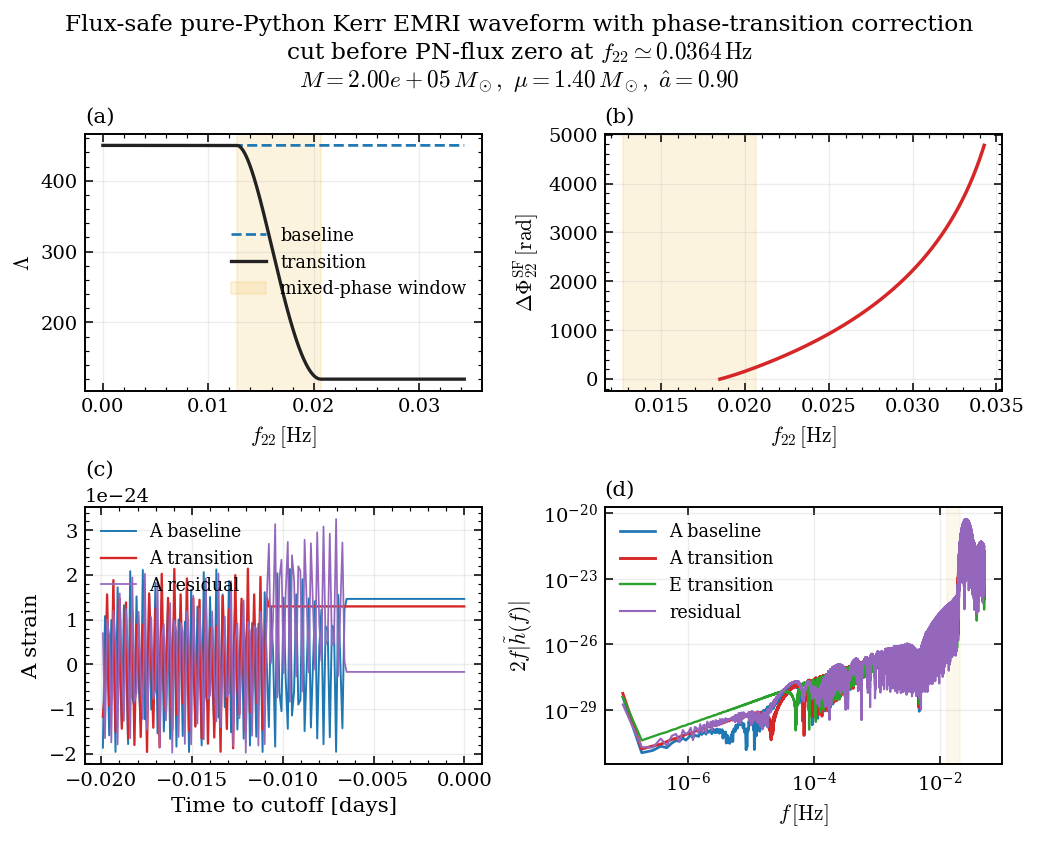

Data saved with prefix: gw_transition_fluxsafe
Run summary
Tobs                      = 0.35 yr
Spin ahat                 = +0.900
Transition model          = mixed
Transition freq window    = 1.269972e-02 -- 2.067938e-02 Hz
Cutoff reason             = flux-root-limited
Flux zero at v_root       = 0.48301501
Flux zero at f22_root     = 3.64115651e-02 Hz
Used v_end                = 0.47335471
Used f22_end              = 3.42702738e-02 Hz
Observed f22 start (base) = 1.84772284e-02 Hz
Observed f22 start (tr)   = 1.84981960e-02 Hz
Observed f22 end (base)   = 3.42702738e-02 Hz
Observed f22 end (tr)     = 3.42702738e-02 Hz
Final same-freq deltaPhi  = 4779.480207 rad
Min baseline Lambda       = 450.000000
Min transition Lambda     = 120.000000


In [29]:
# ============================================================
res = run_model(pars)
plot_results_journal(res, pars, savepath=pars["figure_name"] if pars["save_figure"] else None)

if pars["save_data"]:
    export_data(res, pars)

print("=" * 72)
print("Run summary")
print("=" * 72)
band_type, f1, f2 = transition_band_in_frequency(pars)
print(f"Tobs                      = {pars['Tobs_yr']} yr")
print(f"Spin ahat                 = {pars['ahat']:+.3f}")
print(f"Transition model          = {pars['transition_model']}")
print(f"Transition freq window    = {f1:.6e} -- {f2:.6e} Hz")
print(f"Cutoff reason             = {res['cutoff_reason']}")
if res["v_root"] is not None:
    print(f"Flux zero at v_root       = {res['v_root']:.8f}")
    print(f"Flux zero at f22_root     = {f22_of_v(res['v_root'], pars):.8e} Hz")
print(f"Used v_end                = {res['v_end']:.8f}")
print(f"Used f22_end              = {f22_of_v(res['v_end'], pars):.8e} Hz")
print(f"Observed f22 start (base) = {res['f22_base_t'][0]:.8e} Hz")
print(f"Observed f22 start (tr)   = {res['f22_tr_t'][0]:.8e} Hz")
print(f"Observed f22 end (base)   = {res['f22_base_t'][-1]:.8e} Hz")
print(f"Observed f22 end (tr)     = {res['f22_tr_t'][-1]:.8e} Hz")
print(f"Final same-freq deltaPhi  = {res['delta_phi_sf'][-1]:.6f} rad")
print(f"Min baseline Lambda       = {np.min(res['Lambda_base_full']):.6f}")
print(f"Min transition Lambda     = {np.min(res['Lambda_tr_full']):.6f}")